In [ ]:
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d abdulkader90/brain-ct-hemorrhage-dataset
!unzip brain-ct-hemorrhage-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_83.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_84.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_85.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_86.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_87.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_88.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_89.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_9.jpg  
  inflating: Data/Hemorrhagic/KANAMA/3[3]/ventrik├╝ler-parankimal kanama_0_90.jpg  
  inflating: Data/Hemorrhagic/KANAMA/4[4]/4_0_10.jpg  
  inflating: Data/Hemorrhagic/KANAMA/4[4]/4_0_100.jpg  
  inflating: Data/Hemorrhagic/KANAMA/4[4]/4_0_101.jpg  
  inflating: Data/Hemorrhag

In [ ]:
import os

def count_images(root):
    count = 0
    for _, _, files in os.walk(root):
        count += len([f for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))])
    return count

print("Hemorrhagic images:", count_images("Data/Hemorrhagic"))
print("Normal images:", count_images("Data/NORMAL"))

Hemorrhagic images: 2690
Normal images: 4105


In [ ]:
import os
import shutil
from tqdm import tqdm

OUT_DIR = "dataset"
os.makedirs(f"{OUT_DIR}/hemorrhage", exist_ok=True)
os.makedirs(f"{OUT_DIR}/normal", exist_ok=True)

def flatten_recursive(src_root, dst_root, prefix):
    idx = 0
    for root, _, files in os.walk(src_root):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                src = os.path.join(root, f)
                dst = os.path.join(dst_root, f"{prefix}_{idx}.png")
                shutil.copy(src, dst)
                idx += 1

flatten_recursive("Data/Hemorrhagic", "dataset/hemorrhage", "hem")
flatten_recursive("Data/NORMAL", "dataset/normal", "norm")

print("✅ Dataset flattened successfully")

✅ Dataset flattened successfully


In [ ]:
print("Hemorrhage:", len(os.listdir("dataset/hemorrhage")))
print("Normal:", len(os.listdir("dataset/normal")))

Hemorrhage: 2690
Normal: 4105


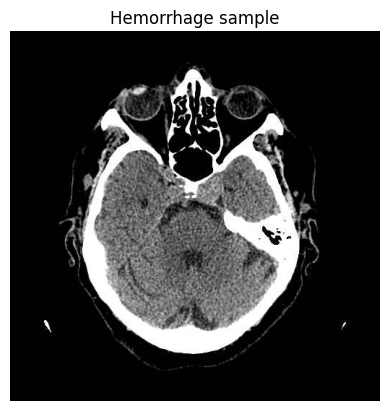

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random

def show_random(path, title):
    img = random.choice(os.listdir(path))
    img = Image.open(os.path.join(path, img))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis("off")

show_random("dataset/hemorrhage", "Hemorrhage sample")

In [ ]:
import os
import random
import shutil

random.seed(42)

HEM_DIR = "dataset/hemorrhage"
NOR_DIR = "dataset/normal"

BAL_DIR = "balanced_dataset"
os.makedirs(f"{BAL_DIR}/hemorrhage", exist_ok=True)
os.makedirs(f"{BAL_DIR}/normal", exist_ok=True)

hem_images = os.listdir(HEM_DIR)
nor_images = os.listdir(NOR_DIR)

nor_sample = random.sample(nor_images, len(hem_images))

for img in hem_images:
    shutil.copy(os.path.join(HEM_DIR, img),
                os.path.join(f"{BAL_DIR}/hemorrhage", img))

for img in nor_sample:
    shutil.copy(os.path.join(NOR_DIR, img),
                os.path.join(f"{BAL_DIR}/normal", img))

print("Balanced dataset created")
print("Hemorrhage:", len(os.listdir(f"{BAL_DIR}/hemorrhage")))
print("Normal:", len(os.listdir(f"{BAL_DIR}/normal")))

Balanced dataset created
Hemorrhage: 2690
Normal: 2690


In [ ]:
from sklearn.model_selection import train_test_split

FINAL_DIR = "final_dataset"
for split in ["train", "val"]:
    for cls in ["hemorrhage", "normal"]:
        os.makedirs(f"{FINAL_DIR}/{split}/{cls}", exist_ok=True)

def split_and_copy(src_dir, cls):
    images = os.listdir(src_dir)
    train_imgs, val_imgs = train_test_split(
        images, test_size=0.2, random_state=42
    )

    for img in train_imgs:
        shutil.copy(os.path.join(src_dir, img),
                    os.path.join(f"{FINAL_DIR}/train/{cls}", img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_dir, img),
                    os.path.join(f"{FINAL_DIR}/val/{cls}", img))

split_and_copy(f"{BAL_DIR}/hemorrhage", "hemorrhage")
split_and_copy(f"{BAL_DIR}/normal", "normal")

print("Train hemorrhage:", len(os.listdir(f"{FINAL_DIR}/train/hemorrhage")))
print("Train normal:", len(os.listdir(f"{FINAL_DIR}/train/normal")))
print("Val hemorrhage:", len(os.listdir(f"{FINAL_DIR}/val/hemorrhage")))
print("Val normal:", len(os.listdir(f"{FINAL_DIR}/val/normal")))

Train hemorrhage: 2152
Train normal: 2152
Val hemorrhage: 538
Val normal: 538


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(
    rescale=1./255
)

val_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_directory(
    "final_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_data = val_gen.flow_from_directory(
    "final_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4304 images belonging to 2 classes.
Found 1076 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
EPOCHS = 30  # allow more, early stopping will decide

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


269/269 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.5322 - loss: 0.6975 - val_accuracy: 0.5000 - val_loss: 0.9394
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6626 - loss: 0.6010 - val_accuracy: 0.5000 - val_loss: 0.9817
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7256 - loss: 0.5410 - val_accuracy: 0.7277 - val_loss: 0.5173
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.7747 - loss: 0.4871 - val_accuracy: 0.5353 - val_loss: 1.0901
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8152 - loss: 0.4315 - val_accuracy: 0.8299 - val_loss: 0.4166
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8795 - loss: 0.3435 - val_accuracy: 0.8903 - val_loss: 0.3314
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8893 - loss: 0.3090 - val_accuracy: 0.6533 - val_loss: 0.5822
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9243 - loss: 0.2426 - val_accurac

In [ ]:
model.save("phase1_kesava.h5")

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

In [ ]:
val_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_aug = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9662 - loss: 0.1082 - val_accuracy: 0.9201 - val_loss: 0.2109
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9752 - loss: 0.0896 - val_accuracy: 0.9507 - val_loss: 0.1319
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.9805 - loss: 0.0780 - val_accuracy: 0.9684 - val_loss: 0.0969
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.9763 - loss: 0.0809 - val_accuracy: 0.8559 - val_loss: 0.4478
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9798 - loss: 0.0729 - val_accuracy: 0.8448 - val_loss: 0.3398
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.9848 - loss: 0.0584 - val_accuracy: 0.9545 - val_loss: 0.1255
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9868 - loss: 0.0513 - val_accuracy: 0.9823 - val_loss: 0.0589
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9868 - loss: 0.0477 - 

In [ ]:
model.save("phase2_kesava.h5")


#RESNET50

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "final_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_data = val_gen.flow_from_directory(
    "final_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4304 images belonging to 2 classes.
Found 1076 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # 🔒 freeze backbone

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.5220 - loss: 0.7518 - val_accuracy: 0.5223 - val_loss: 0.6829
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 60s 224ms/step - accuracy: 0.5492 - loss: 0.6923 - val_accuracy: 0.5446 - val_loss: 0.6773
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 62s 231ms/step - accuracy: 0.5554 - loss: 0.6784 - val_accuracy: 0.6413 - val_loss: 0.6512
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 227ms/step - accuracy: 0.5794 - loss: 0.6697 - val_accuracy: 0.6385 - val_loss: 0.6452
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 225ms/step - accuracy: 0.6180 - loss: 0.6574 - val_accuracy: 0.6533 - val_loss: 0.6378
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 233ms/step - accuracy: 0.6197 - loss: 0.6527 - val_accuracy: 0.6143 - val_loss: 0.6345
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 228ms/step - accuracy: 0.6112 - loss: 0.6505 - val_accuracy: 0.6571 - val_loss: 0.6168
Epoch 8/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 229ms/step - accuracy: 0.6432 - loss: 0

#finetune


In [ ]:
# Unfreeze top layers of ResNet50
for layer in base_model.layers[-40:]:
    layer.trainable = True


In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_resnet_ft = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 89s 257ms/step - accuracy: 0.6454 - loss: 0.7962 - val_accuracy: 0.7900 - val_loss: 0.4274
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 64s 237ms/step - accuracy: 0.7968 - loss: 0.4205 - val_accuracy: 0.8104 - val_loss: 0.3967
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 62s 232ms/step - accuracy: 0.8497 - loss: 0.3294 - val_accuracy: 0.8690 - val_loss: 0.2967
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 233ms/step - accuracy: 0.8967 - loss: 0.2578 - val_accuracy: 0.9099 - val_loss: 0.2312
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 62s 231ms/step - accuracy: 0.8963 - loss: 0.2408 - val_accuracy: 0.8810 - val_loss: 0.2684
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 233ms/step - accuracy: 0.9046 - loss: 0.2431 - val_accuracy: 0.9052 - val_loss: 0.2435
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 227ms/step - accuracy: 0.9313 - loss: 0.1884 - val_accuracy: 0.9182 - val_loss: 0.1990
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 228ms/step - accuracy: 0.9172 - loss: 0

In [ ]:
model_resnet.save("phase2_resnet50_finetuned.h5")

#Efficientnet50

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# 🔓 Unfreeze top layers directly
for layer in base_model.layers[-40:]:
    layer.trainable = True

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model_eff = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=12,   # ⏱️ FAST
    callbacks=[early_stop]
)

Epoch 1/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 162s 304ms/step - accuracy: 0.5454 - loss: 0.6875 - val_accuracy: 0.4991 - val_loss: 0.7001
Epoch 2/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 235ms/step - accuracy: 0.6473 - loss: 0.6331 - val_accuracy: 0.5493 - val_loss: 0.6934
Epoch 3/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 64s 237ms/step - accuracy: 0.7485 - loss: 0.5650 - val_accuracy: 0.5418 - val_loss: 0.7347
Epoch 4/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 66s 245ms/step - accuracy: 0.7838 - loss: 0.4978 - val_accuracy: 0.4888 - val_loss: 0.7056
Epoch 5/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 70s 262ms/step - accuracy: 0.8239 - loss: 0.4302 - val_accuracy: 0.5325 - val_loss: 0.6850
Epoch 6/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 64s 238ms/step - accuracy: 0.8550 - loss: 0.3543 - val_accuracy: 0.6506 - val_loss: 0.6064
Epoch 7/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 64s 238ms/step - accuracy: 0.8625 - loss: 0.3145 - val_accuracy: 0.4954 - val_loss: 0.7174
Epoch 8/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 236ms/step - accuracy: 0.8905 - loss: 

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Unfreeze top layers directly
for layer in base_model.layers[-30:]:
    layer.trainable = True

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=15,   # ⏱️ FAST
    callbacks=[early_stop]
)

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 124s 271ms/step - accuracy: 0.5529 - loss: 0.7312 - val_accuracy: 0.5929 - val_loss: 0.6720
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 226ms/step - accuracy: 0.7179 - loss: 0.5512 - val_accuracy: 0.6422 - val_loss: 0.6203
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 225ms/step - accuracy: 0.8176 - loss: 0.4166 - val_accuracy: 0.6636 - val_loss: 0.5863
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 65s 241ms/step - accuracy: 0.8804 - loss: 0.3139 - val_accuracy: 0.6719 - val_loss: 0.5748
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 228ms/step - accuracy: 0.8965 - loss: 0.2613 - val_accuracy: 0.7565 - val_loss: 0.4862
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 62s 229ms/step - accuracy: 0.9251 - loss: 0.2048 - val_accuracy: 0.7667 - val_loss: 0.4661
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 226ms/step - accuracy: 0.9349 - loss: 0.1755 - val_accuracy: 0.7686 - val_loss: 0.4632
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 228ms/step - accuracy: 0.9449 - loss: 

In [ ]:
model_eff.save("phase2_efficientnet_rejected.h5") ##save efficient model

In [ ]:
model_mobilenet.save("phase2_mobilenetv2.h5")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model("phase2_kesava.h5")
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,787 (432.77 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d Conv2D
batch_normalization BatchNormalization
max_pooling2d MaxPooling2D
conv2d_1 Conv2D
batch_normalization_1 BatchNormalization
max_pooling2d_1 MaxPooling2D
conv2d_2 Conv2D
batch_normalization_2 BatchNormalization
max_pooling2d_2 MaxPooling2D
global_average_pooling2d GlobalAveragePooling2D
dense Dense
dropout Dropout
dense_1 Dense


In [ ]:
import tensorflow as tf

# Create a new functional model from the Sequential model
inputs = tf.keras.Input(shape=(224, 224, 3))
outputs = model(inputs, training=False)

functional_model = tf.keras.Model(inputs=inputs, outputs=outputs)

functional_model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 1)              │       110,785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
!pip install tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00


In [ ]:
from tf_explain.core.grad_cam import GradCAM
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
model = load_model("phase2_kesava.h5")

In [ ]:
ls final_dataset/val/hemorrhage | head

hem_1006.png
hem_1008.png
hem_1014.png
hem_101.png
hem_1020.png
hem_1025.png
hem_1027.png
hem_1029.png
hem_1034.png
hem_103.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "final_dataset/val/hemorrhage/hem_1008.png"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))

img_norm = img.astype("float32") / 255.0
img_rgb = np.stack([img_norm]*3, axis=-1)
img_array = np.expand_dims(img_rgb, axis=0)

In [ ]:
def occlusion_sensitivity(model, img, patch=16):
    h, w = img.shape[:2]
    baseline = model.predict(img_array)[0][0]
    heatmap = np.zeros((h, w))

    for y in range(0, h, patch):
        for x in range(0, w, patch):
            occluded = img.copy()
            occluded[y:y+patch, x:x+patch] = 0

            oc_rgb = np.stack([occluded]*3, axis=-1)
            oc_rgb = np.expand_dims(oc_rgb, axis=0)

            pred = model.predict(oc_rgb)[0][0]
            heatmap[y:y+patch, x:x+patch] = abs(baseline - pred)

    heatmap /= heatmap.max()
    return heatmap

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

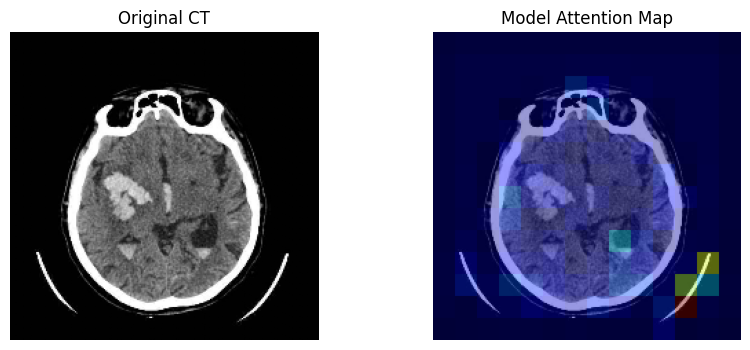

In [ ]:
heatmap = occlusion_sensitivity(model, img_norm)

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap), cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    cv2.cvtColor(img, cv2.COLOR_GRAY2BGR),
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original CT")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Model Attention Map")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np

def load_ct_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224,224))
    img_norm = img.astype("float32") / 255.0
    img_rgb = np.stack([img_norm]*3, axis=-1)
    img_array = np.expand_dims(img_rgb, axis=0)
    return img, img_norm, img_array

In [ ]:
def occlusion_sensitivity(model, img_norm, patch=16):
    h, w = img_norm.shape
    baseline = model.predict(
        np.expand_dims(np.stack([img_norm]*3, axis=-1), axis=0),
        verbose=0
    )[0][0]

    heatmap = np.zeros((h, w))

    for y in range(0, h, patch):
        for x in range(0, w, patch):
            occluded = img_norm.copy()
            occluded[y:y+patch, x:x+patch] = 0

            oc_rgb = np.stack([occluded]*3, axis=-1)
            oc_rgb = np.expand_dims(oc_rgb, axis=0)

            pred = model.predict(oc_rgb, verbose=0)[0][0]
            heatmap[y:y+patch, x:x+patch] = abs(baseline - pred)

    heatmap /= heatmap.max() + 1e-8
    return heatmap

In [ ]:
import matplotlib.pyplot as plt

def show_occlusion(img, heatmap, title):
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap), cv2.COLORMAP_JET
    )
    overlay = cv2.addWeighted(
        cv2.cvtColor(img, cv2.COLOR_GRAY2BGR),
        0.6, heatmap_color, 0.4, 0
    )

    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

def saliency_map(model, img_array):
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model(img_tensor)
        loss = prediction[:, 0]   # binary classifier

    grads = tape.gradient(loss, img_tensor)

    # Take max gradient across color channels
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    saliency = saliency.numpy()
    saliency /= saliency.max() + 1e-8

    return saliency

In [ ]:
def show_saliency(img, saliency, title):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap="gray")
    plt.imshow(saliency, cmap="jet", alpha=0.5)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
def prediction_difference(model, img_norm):
    original_pred = model.predict(
        np.expand_dims(np.stack([img_norm]*3, axis=-1), axis=0),
        verbose=0
    )[0][0]

    masked = img_norm.copy()
    masked[img_norm > 0.7] = 0  # mask bright regions

    masked_pred = model.predict(
        np.expand_dims(np.stack([masked]*3, axis=-1), axis=0),
        verbose=0
    )[0][0]

    return original_pred, masked_pred, masked

In [ ]:
def show_prediction_diff(img, masked, p1, p2, title):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Original (Pred={p1:.2f})")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(masked, cmap="gray")
    plt.title(f"Masked (Pred={p2:.2f})")
    plt.axis("off")

    plt.suptitle(title)
    plt.show()

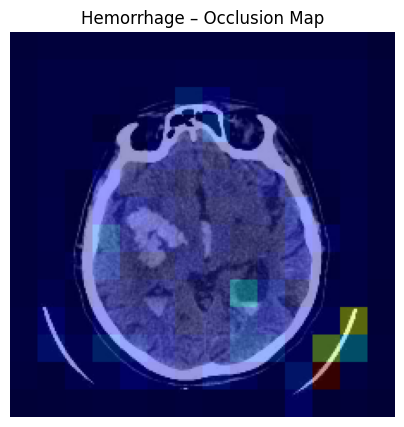

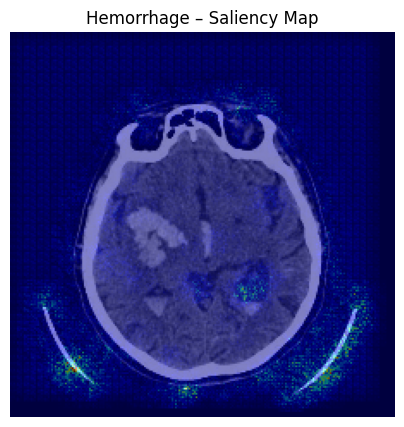

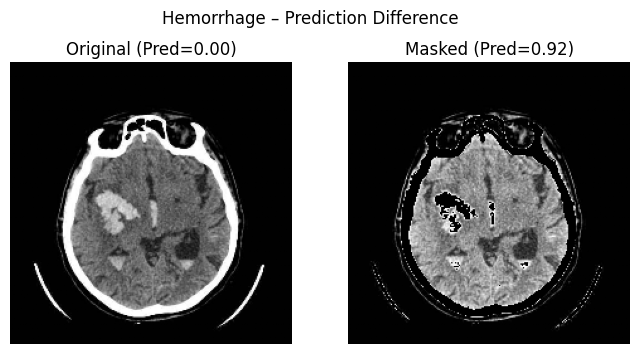

In [ ]:
img_path = "final_dataset/val/hemorrhage/hem_1008.png"
img, img_norm, img_array = load_ct_image(img_path)

heatmap = occlusion_sensitivity(model, img_norm)
show_occlusion(img, heatmap, "Hemorrhage – Occlusion Map")

sal = saliency_map(model, img_array)
show_saliency(img, sal, "Hemorrhage – Saliency Map")

p1, p2, masked = prediction_difference(model, img_norm)
show_prediction_diff(img, masked, p1, p2, "Hemorrhage – Prediction Difference")

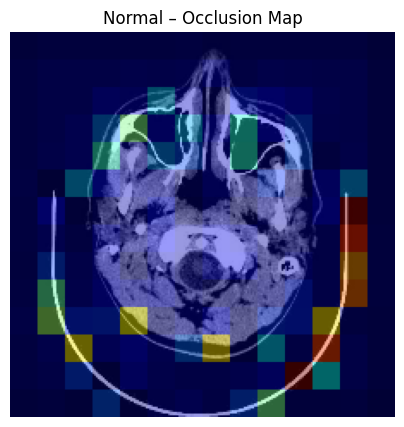

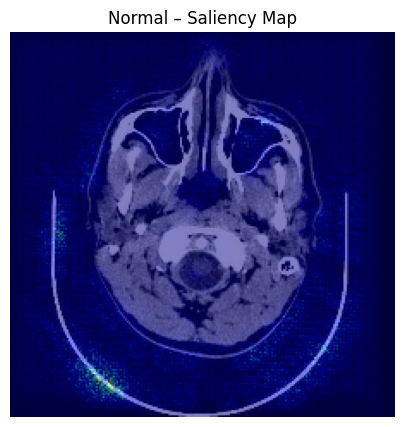

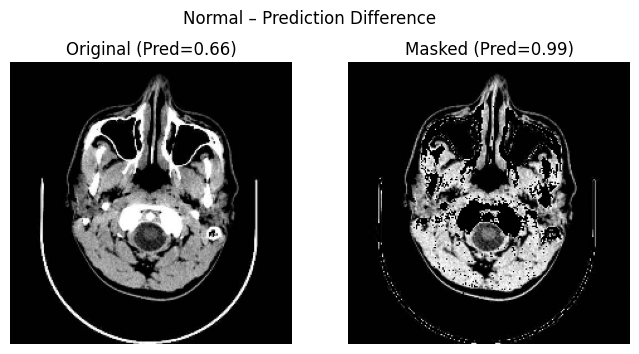

In [ ]:
img_path = "final_dataset/val/normal/norm_1003.png"
img, img_norm, img_array = load_ct_image(img_path)

heatmap = occlusion_sensitivity(model, img_norm)
show_occlusion(img, heatmap, "Normal – Occlusion Map")

sal = saliency_map(model, img_array)
show_saliency(img, sal, "Normal – Saliency Map")

p1, p2, masked = prediction_difference(model, img_norm)
show_prediction_diff(img, masked, p1, p2, "Normal – Prediction Difference")

In [ ]:
print(train_data.class_indices)

{'hemorrhage': 0, 'normal': 1}


In [ ]:
!zip -r final_dataset.zip final_dataset

Streaming output truncated to the last 5000 lines.
  adding: final_dataset/train/hemorrhage/hem_1587.png (deflated 2%)
  adding: final_dataset/train/hemorrhage/hem_765.png (deflated 16%)
  adding: final_dataset/train/hemorrhage/hem_344.png (deflated 22%)
  adding: final_dataset/train/hemorrhage/hem_1808.png (deflated 10%)
  adding: final_dataset/train/hemorrhage/hem_1277.png (deflated 16%)
  adding: final_dataset/train/hemorrhage/hem_1594.png (deflated 3%)
  adding: final_dataset/train/hemorrhage/hem_93.png (deflated 11%)
  adding: final_dataset/train/hemorrhage/hem_1022.png (deflated 10%)
  adding: final_dataset/train/hemorrhage/hem_228.png (deflated 9%)
  adding: final_dataset/train/hemorrhage/hem_585.png (deflated 24%)
  adding: final_dataset/train/hemorrhage/hem_1361.png (deflated 11%)
  adding: final_dataset/train/hemorrhage/hem_925.png (deflated 16%)
  adding: final_dataset/train/hemorrhage/hem_1457.png (deflated 3%)
  adding: final_dataset/train/hemorrhage/hem_1854.png (deflated

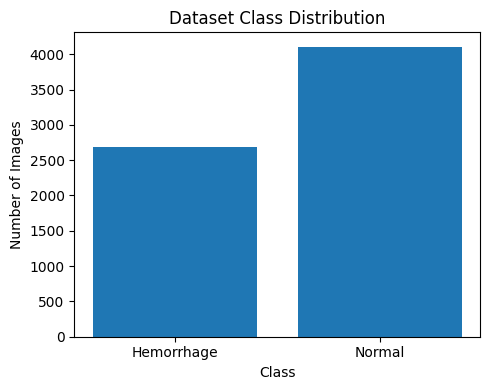

In [ ]:
import matplotlib.pyplot as plt

classes = ["Hemorrhage", "Normal"]
counts = [2690, 4105]  # replace if you updated numbers

plt.figure(figsize=(5,4))
plt.bar(classes, counts)
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.tight_layout()
plt.show()

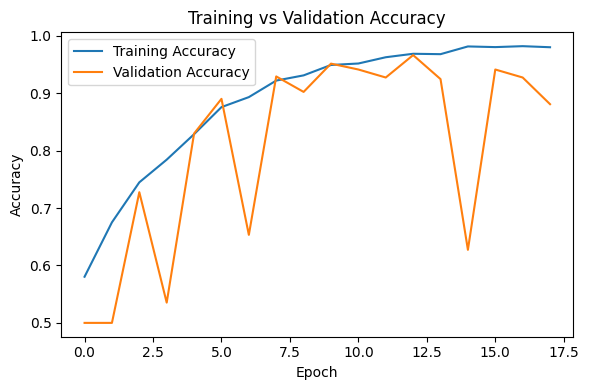

In [ ]:
history = history.history  # use the history from best CNN model

plt.figure(figsize=(6,4))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

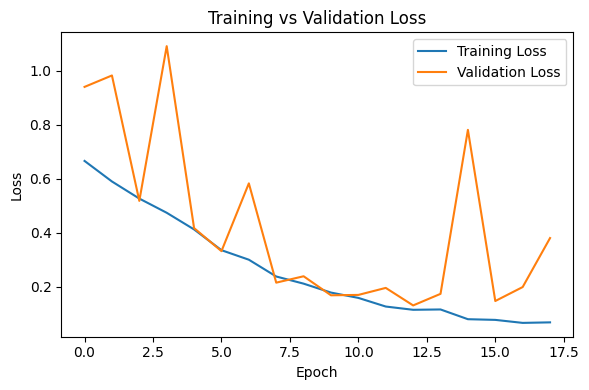

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step


<Figure size 500x500 with 0 Axes>

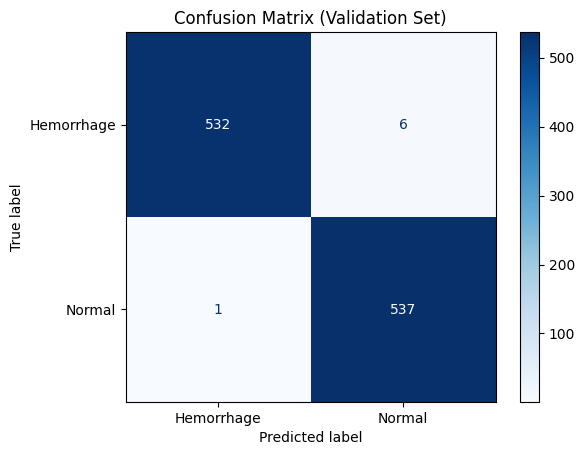

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = val_data.classes
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Hemorrhage", "Normal"]
)

plt.figure(figsize=(5,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

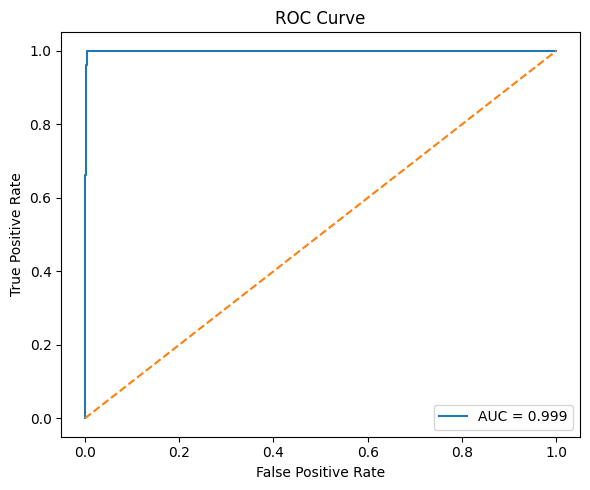

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
model = tf.keras.models.load_model("phase2_kesava.h5")

In [ ]:
def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.stack([img]*3, axis=-1)
    img = np.expand_dims(img, axis=0)
    return img

In [ ]:
def occlusion_map(model, img, patch_size=32):
    base_pred = model.predict(img)[0][0]
    heatmap = np.zeros((224, 224))

    for y in range(0, 224, patch_size):
        for x in range(0, 224, patch_size):
            occluded = img.copy()
            occluded[:, y:y+patch_size, x:x+patch_size, :] = 0
            pred = model.predict(occluded)[0][0]
            heatmap[y:y+patch_size, x:x+patch_size] = abs(base_pred - pred)

    heatmap = heatmap / heatmap.max()
    return heatmap

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━

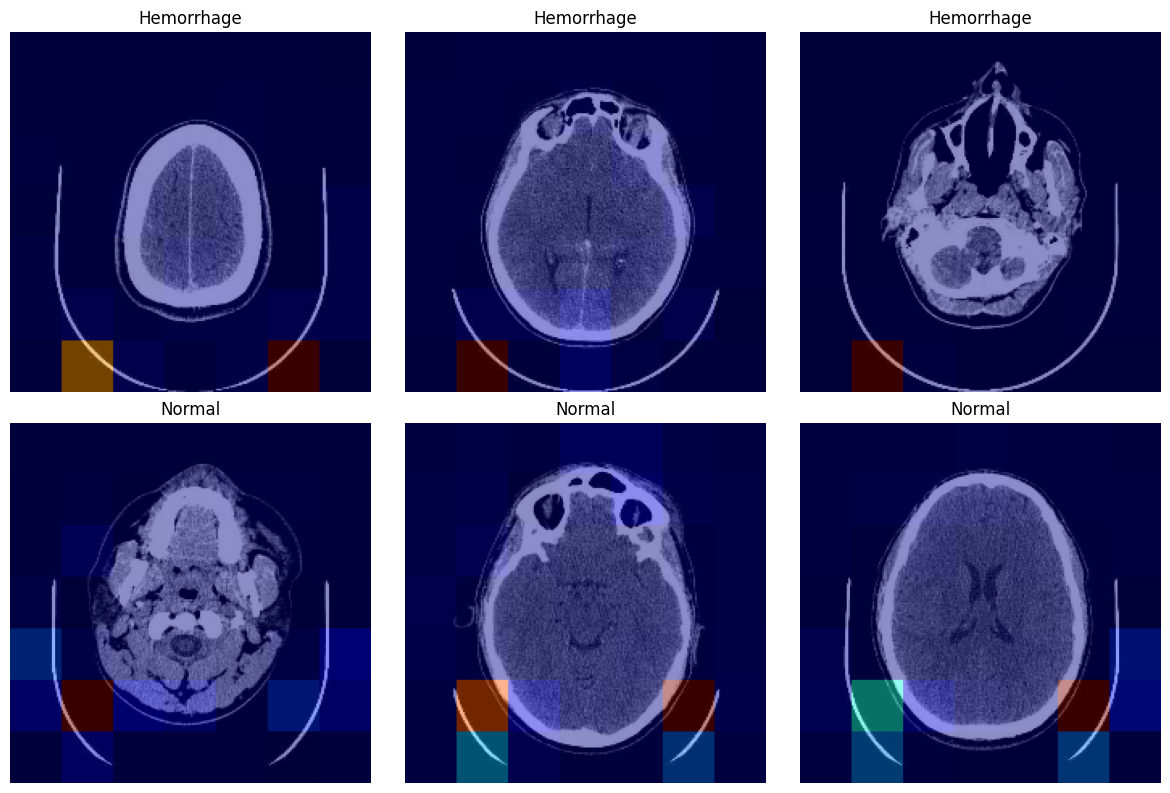

In [ ]:
images = [
    ("hem_0.png", "Hemorrhage"),
    ("hem_2.png", "Hemorrhage"),
    ("hem_3.png", "Hemorrhage"),
    ("norm_0.png", "Normal"),
    ("norm_2.png", "Normal"),
    ("norm_3.png", "Normal"),
]

plt.figure(figsize=(12, 8))

for i, (path, label) in enumerate(images):
    img = preprocess_image(path)
    heatmap = occlusion_map(model, img)

    original = cv2.imread(path)
    original = cv2.resize(original, (224,224))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(original)
    plt.imshow(heatmap, cmap="jet", alpha=0.45)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.savefig("Fig5_Occlusion_Subplots.png", dpi=300)
plt.show()